# SparsePEA — Tutorial

**Simon Mishricky**

This notebook walks through the `sparsepea` package by solving three
DSGE models with occasionally binding constraints:

1. **Real Business Cycle (RBC)** with irreversible investment.
2. **Diamond–Mortensen–Pissarides (DMP)** search-and-matching, in the
   Hagedorn–Manovskii (2008) calibration.
3. **Endogenous Disasters**, replicating the baseline model of
   Petrosky-Nadeau, Zhang & Kuehn (2018, *American Economic Review*).

All three are solved with the Parameterised Expectations Algorithm (PEA)
on Tasmanian sparse grids — a combination that scales well to higher
dimensions and handles non-differentiable kinks in the policy function
without smoothing or penalty methods. The third model is the most
challenging numerically: a consumption-based stochastic discount factor
amplifies fixed-point updates enough that damped iteration is required
for stability.

## Background

### Why PEA?

Many DSGE models contain Euler equations of the form

$$g(x_t) = \mathbb{E}_t\bigl[h(x_t, x_{t+1})\bigr]$$

where the right-hand side involves a conditional expectation that cannot be
evaluated in closed form. Perturbation methods linearise or take low-order
Taylor expansions around a steady state, which works well when the model is
smooth but breaks down near occasionally binding constraints — the kink
introduced by a constraint like $K' \geq (1-\delta)K$ makes the policy
function non-differentiable, so local approximations miss the binding region
entirely.

The **Parameterised Expectations Algorithm** (PEA) avoids this problem by
working with a global approximation. Rather than expanding around a single
point, the PEA parameterises the conditional expectation itself:

$$\psi(x_t) \approx \mathbb{E}_t\bigl[h(x_t, x_{t+1})\bigr]$$

and iterates on the functional equation until $\psi$ converges. At each
iteration, complementarity conditions (e.g. the KKT conditions for
irreversible investment) are checked pointwise, so the constraint can bind
at some grid points and not others — no smoothing is needed.

### Why sparse grids?

The PEA requires evaluating and updating $\psi$ on a grid of state-space
points. With a standard tensor-product grid, the number of points grows
exponentially in the number of state variables — a phenomenon known as the
*curse of dimensionality*. For a grid with $n$ points per dimension and $d$
dimensions, a tensor grid has $n^d$ points: manageable when $d = 2$, but
infeasible for the $d = 4$ or $d = 5$ models that arise in applied work.

Sparse grids (Smolyak, 1963) break this curse by retaining only the grid
points that contribute the most to interpolation accuracy. The result is a
grid whose size grows *polynomially* rather than exponentially in $d$.
SparsePEA uses the [Tasmanian](https://github.com/ORNL/TASMANIAN) library from
Oak Ridge National Laboratory, which provides local polynomial sparse grids
for both interpolation and numerical integration (quadrature).

In [1]:
import numpy as np
from sparsepea.models import rbc_jit, dmp_jit, end_dmp_jit
from sparsepea.tools import tools

## Initial guesses

Every fixed-point iteration needs a starting point. For the PEA, we need
an initial guess of the expectation function $\psi(\mathbf{s})$ evaluated
at each node of the sparse grid.

A good heuristic is the *certainty-equivalent* (perfect-foresight)
solution: set the shock to its unconditional mean and solve the resulting
deterministic Euler equation. For the RBC model this yields a log-linear
guess in $(K, Z)$; for the DMP model a simple linear guess in $(N, X)$
suffices.

For the endogenous-disaster model (Section 3) the picture is different.
The consumption-based SDF amplifies the iteration enough that a
perfect-foresight guess far from the constraint can send the iteration
off to infinity. There we use a *flat* guess that sits exactly at the
zero-vacancy boundary, which keeps the first iteration in a region
where the SDF is bounded.

Iteration counts:

| Model | Iterations to converge | Notes |
|:------|:----------------------:|:------|
| RBC                       | ~320  | undamped (`damping=1.0`) |
| DMP (Hagedorn–Manovskii)  | ~520  | undamped |
| Endogenous Disasters      | ~1060 | damped (`damping=0.1`) |

All counts are with `depth=8`, `order=1` local polynomial grids and the
default sup-norm tolerance $10^{-5}$.

In [2]:
# Certainty-equivalent log-linear guess for the RBC expectation function.
# Coefficients γ are derived from the steady-state log-Euler equation.
α = 0.33
δ = 0.025
y_k = 0.11210762331838565
β = 1.0 / (α * y_k + 1.0 - δ)

γ_rbc = np.array([-np.log(1 - α * β), -α, -1.0])


def initial_guess_rbc(grid_states, γ):
    '''Log-linear guess ψ(K, Z) = exp(γ₀ + γ₁·logK + γ₂·logZ).'''

    grid_size = grid_states[:, 1].size
    guess = np.zeros([grid_size, 1])

    for i in range(grid_size):
        k, z = grid_states[i, 0], grid_states[i, 1]
        guess[i, :] = np.exp(γ[0] + γ[1] * np.log(k) + γ[2] * np.log(z))

    return guess


def initial_guess_dmp(grid_states, γ):
    '''Linear guess ψ(N, X) = γ₀ + γ₁·N + γ₂·X.'''

    grid_size = grid_states[:, 1].size
    guess = np.zeros([grid_size, 1])

    for i in range(grid_size):
        n, x = grid_states[i, 0], grid_states[i, 1]
        guess[i, :] = γ[0] + γ[1] * n + γ[2] * x

    return guess

## 1. Real Business Cycle with Irreversible Investment

### The model

The RBC model with irreversible investment is one of the simplest settings
in which an occasionally binding constraint matters quantitatively. A social
planner chooses a sequence of capital stocks to maximise discounted lifetime
utility:

$$v(K, Z) = \max_{K' \in \mathcal{D}_{K,Z}}\; u(C) + \beta\, \mathbb{E}\!\left[v(K', Z') \mid Z\right]$$

subject to a resource constraint and a non-negativity constraint on gross
investment:

$$C = Z K^\alpha + (1-\delta) K - K', \qquad
K' \geq (1-\delta) K$$

Total factor productivity (TFP) follows a log-AR(1) process:

$$\ln Z' = \rho \ln Z + \sigma\varepsilon', \qquad \varepsilon' \sim N(0,1)$$

with CRRA preferences $u(C) = \frac{C^{1-\eta}-1}{1-\eta}$.

### Euler equation and complementarity conditions

Taking first-order conditions and letting $\mu \geq 0$ denote the KKT
multiplier on the irreversibility constraint yields:

$$C^{-\eta} - \mu
= \beta\, \mathbb{E}\!\left[
  C'^{-\eta}\bigl(1 - \delta + \alpha Z' K'^{\alpha-1}\bigr)
  - \mu'(1-\delta)
\right]$$

with the complementary slackness conditions

$$\mu \geq 0, \qquad K' - (1-\delta)K \geq 0, \qquad \mu\bigl[K' - (1-\delta)K\bigr] = 0.$$

These conditions partition the state space into two regions. In the *interior*
region, the constraint does not bind ($\mu = 0$) and the planner freely
chooses investment. In the *constrained* region, gross investment is zero
($K' = (1-\delta)K$), the household consumes all output ($C = ZK^\alpha$),
and $\mu > 0$ captures the shadow value of the binding constraint.

The PEA parameterises the right-hand side of the Euler equation as
$\psi(K, Z)$ and iterates until convergence. At each grid point the
algorithm checks whether the implied $K'$ violates the irreversibility
constraint and enforces the appropriate complementarity condition.

In [ ]:
# Build the model and the solver. Defaults: depth=8, order=1 local-polynomial
# Tasmanian grid (see https://github.com/ORNL/TASMANIAN). RBC needs no damping,
# so we leave damping at its default of 1.0.
rbc_model = rbc_jit()
tool_box = tools(model=rbc_model)
_, grid_states_rbc = tool_box.make_states_grid()

# Construct the certainty-equivalent initial guess and solve.
e0_rbc = initial_guess_rbc(grid_states_rbc, γ_rbc)
e_rbc, c, μ, count_rbc = tool_box.compute_solution(e0_rbc)
print(count_rbc)

In [4]:
%time _ = tool_box.compute_solution(e0_rbc)

CPU times: user 1min 26s, sys: 1.02 s, total: 1min 27s
Wall time: 1min 27s


### Performance notes

The `numba.jitclass` approach used by `sparsepea.models` is somewhat slower
than a flat `@njit` implementation because `jitclass` does not support
`numba.prange` for parallelisation. The trade-off is a clean,
object-oriented model interface that extends to new models without a
shared global state.

| Implementation               | RBC solve time |
|:-----------------------------|:--------------:|
| `jitclass` (this package)    | ~80 s          |
| `njit` + `prange` (reference)| ~55 s          |
| pure Python (reference)      | ~32 min        |

Reference implementations measured on the same Apple M-series laptop.
Numbers for the DMP and endogenous-disaster models follow the same
scaling pattern.

### Visualising the solution

The 3D surface below shows the consumption policy function $C(K, Z)$
interpolated onto a regular grid, with the sparse grid nodes overlaid as
black dots. The surface is smooth in the interior region but exhibits a kink
along the boundary where the irreversibility constraint binds — this is
exactly the non-linearity that perturbation methods struggle to capture.

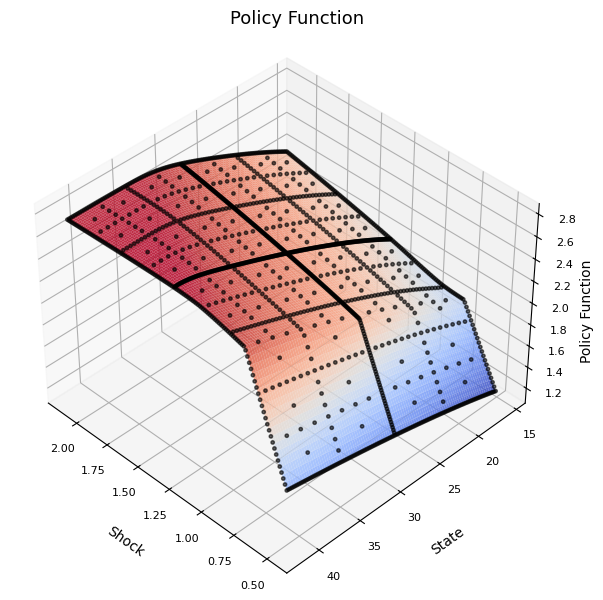

In [5]:
tool_box.plot_policy_3d(c)

### Solution accuracy

A key advantage of projection methods like the PEA is that solution accuracy
can be assessed directly via **Euler equation residuals**. If the solution
were exact, the Euler equation would hold with zero error at every point in
the state space. In practice, we compute

$$\varepsilon(K, Z) = \left|\frac{C(K,Z) - C^{\text{implied}}(K,Z)}{C^{\text{implied}}(K,Z)}\right|$$

where $C^{\text{implied}}$ is the consumption level implied by the converged
expectation function. Residuals below $10^{-3}$ (0.1%) are generally
considered acceptable in the computational economics literature; below
$10^{-4}$ is very good.

We use the standard pattern: `compute_residuals` produces the residual
surface from the converged $\psi$, and `plot_errors_3d` reads the cached
result. Passing the converged $\psi$ (rather than the initial guess)
avoids re-running the solve.

median residual: 3.74e-05


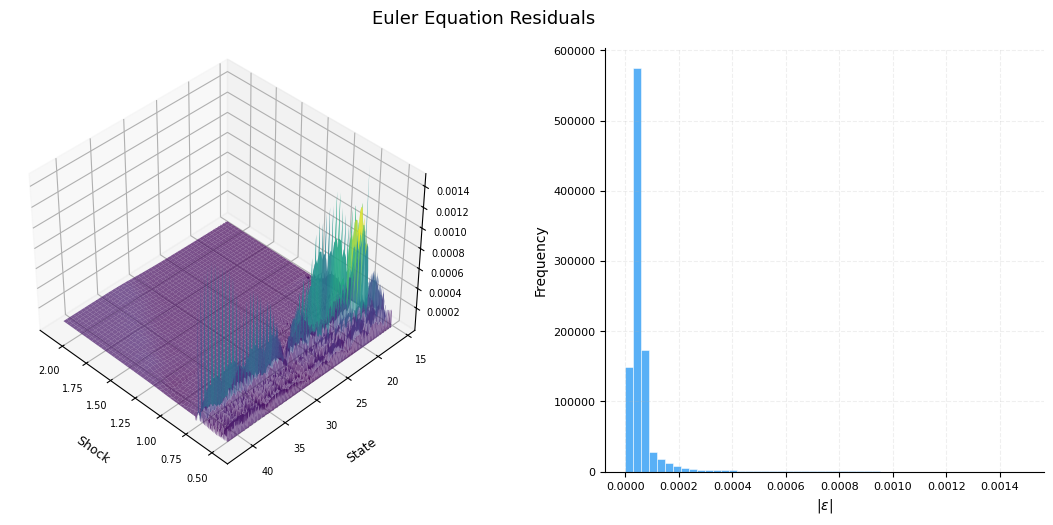

In [6]:
err_rbc = tool_box.compute_residuals(e_rbc)
print(f'median residual: {np.median(err_rbc):.2e}')
tool_box.plot_errors_3d()

## 2. Diamond–Mortensen–Pissarides (Hagedorn–Manovskii)

### The model

The DMP model is the canonical framework for analysing equilibrium
unemployment. Firms post vacancies at a cost, unemployed workers search for
jobs, and a matching function governs the rate at which vacancies and
searchers meet. The Hagedorn and Manovskii (2008) calibration is notable
for generating realistic labour-market volatility — the so-called *Shimer
puzzle* — by setting the flow value of unemployment $b$ close to average
productivity.

### Free-entry condition

Firms post vacancies until the expected cost equals the expected value of a
filled job. The resulting free-entry condition is

$$\frac{\kappa_t}{q(\theta_t)} - \lambda_t
= \beta\, \mathbb{E}\!\left[
  X_{t+1} - W_{t+1}
  + (1-s)\!\left(\frac{\kappa_{t+1}}{q(\theta_{t+1})} - \lambda_{t+1}\right)
\right]$$

where $\theta_t = V_t / (1-N_t)$ is labour-market tightness (the
vacancy–unemployment ratio), $q(\theta_t)$ is the vacancy-filling rate from
a CES matching function, $s$ is the exogenous separation rate, and wages
are Nash-bargained:

$$W_t = \eta\bigl(X_t + \kappa_t\theta_t\bigr) + (1-\eta)\, b$$

The vacancy cost $\kappa_t = \kappa_K X_t + \kappa_W X_t^\xi$ is
state-dependent (increasing in productivity), and $\ln X_{t+1} = \rho \ln X_t +
\sigma\varepsilon_{t+1}$.

### Complementarity conditions

As in the RBC model, there is an occasionally binding constraint: firms
cannot post negative vacancies. When productivity is sufficiently low, no
vacancies are posted ($V_t = 0$, $\theta_t = 0$) and the multiplier
$\lambda_t > 0$ captures the shadow cost of the binding constraint:

$$\lambda_t \geq 0, \qquad q(\theta_t)\, V_t \geq 0, \qquad
\lambda_t\, q(\theta_t)\, V_t = 0$$

This zero-vacancy region is economically important: it corresponds to
episodes in which the labour market is so weak that firms find it
unprofitable to recruit at all.

In [7]:
# Linear initial guess; coefficients tuned so that ψ ≈ steady-state value
# at high employment and drops into the constrained region as N falls.
γ_dmp = np.array([-20.0, 23.18875328038525, 0.0])

In [8]:
# Build the DMP model + solver. Default DMP calibration uses Hagedorn-
# Manovskii (2008) parameters; see sparsepea.models.dmp_jit. No damping
# required (the SDF is constant β in this version).
dmp_model = dmp_jit()
tool_box = tools(model=dmp_model, max_iter=1000)
_, grid_states_dmp = tool_box.make_states_grid()

e0_dmp = initial_guess_dmp(grid_states_dmp, γ_dmp)
e_dmp, θ, λ, count_dmp = tool_box.compute_solution(e0_dmp)
print(count_dmp)

Convergence successful: 521 Iterations


In [9]:
%time _ = tool_box.compute_solution(e0_dmp)

CPU times: user 2min 20s, sys: 1.63 s, total: 2min 22s
Wall time: 2min 22s


### Policy function

The surface below shows labour-market tightness $\theta(N, X)$ as a function
of the two state variables (employment $N$ and productivity $X$). Higher
productivity and lower employment both increase tightness — firms post more
vacancies when output per worker is high and when the pool of available
workers is large.

The flat region at $\theta = 0$ corresponds to the zero-vacancy constraint
binding: when productivity is very low, no vacancies are posted and the
labour market is completely slack.

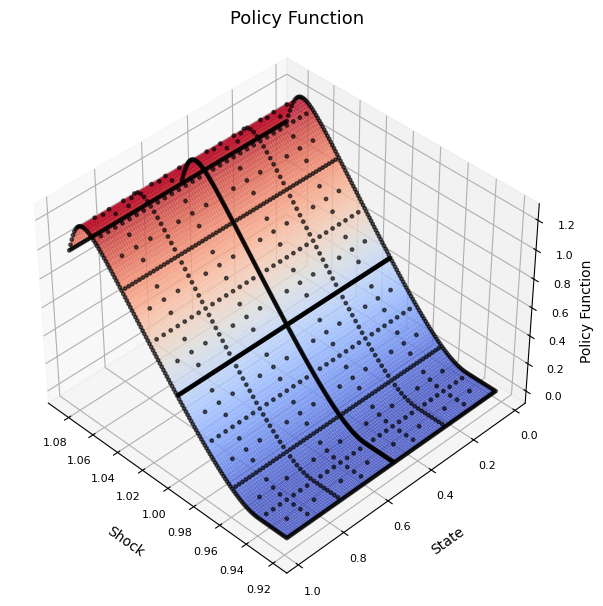

In [10]:
tool_box.plot_policy_3d(θ)

### Euler residuals

median residual: 3.13e-06


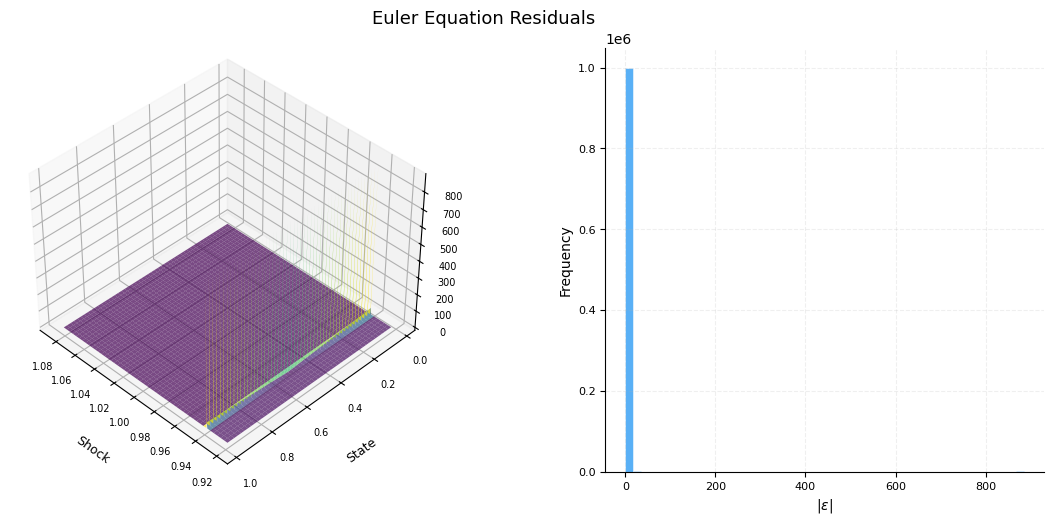

In [11]:
err_dmp = tool_box.compute_residuals(e_dmp)
print(f'median residual: {np.median(err_dmp):.2e}')
tool_box.plot_errors_3d()

## 3. Endogenous Disasters (Petrosky-Nadeau, Zhang & Kuehn, 2018)

### The model

Petrosky-Nadeau, Zhang and Kuehn (2018, *American Economic Review*) show
that the standard DMP search model — once solved with a globally nonlinear
method — *endogenously* generates rare disasters. The key ingredients are
a high flow value of unemployment (which makes wages inertial), a trading
externality in the matching process (which makes the marginal cost of
hiring rigid downward), and crucially the consumption-based stochastic
discount factor that amplifies bad shocks.

The household has log utility, so the stochastic discount factor is

$$M_{t+1} = \beta\,\frac{C_t}{C_{t+1}}.$$

Vacancy posting costs combine a fixed and a recruiting component, the
latter paid in expectation only when a vacancy is filled:

$$\kappa_t = \kappa_0 + \kappa_1\, q(\theta_t).$$

The intertemporal job-creation condition is (eq. 8 of PNZK):

$$\frac{\kappa_0}{q(\theta_t)} + \kappa_1 - \lambda_t
= \mathbb{E}_t\!\left[ M_{t+1}\!\left(
  X_{t+1} - W_{t+1}
  + (1-s)\!\left(\frac{\kappa_0}{q(\theta_{t+1})} + \kappa_1 - \lambda_{t+1}\right)
\right) \right]$$

with the same Kuhn–Tucker conditions $\lambda_t \geq 0$, $q(\theta_t)V_t \geq 0$,
$\lambda_t q(\theta_t) V_t = 0$ on the no-negative-vacancies constraint.
The state is $(N_t, X_t)$; consumption clears the goods market,
$C_t = X_t N_t - \kappa_t V_t$.

**Why disasters arise endogenously.** When cumulative negative shocks push
productivity low, vacancies dry up, $q \to 1$, the effective marginal
cost of hiring $\kappa_0/q + \kappa_1$ fails to fall, and profits collapse.
The consumption-based SDF spikes (because $C_{t+1}$ is small), but the
marginal benefit of hiring also collapses, so job creation is stifled and
employment falls off a cliff. The disaster is not assumed — it falls out
of the same Gaussian shock process used in normal times.

### Numerical considerations

The consumption-based SDF substantially amplifies fixed-point updates
compared with the constant-$\beta$ baseline. Without damping, the PEA
iteration diverges in tens of iterations.

We pass `damping=0.1` to the solver, which replaces
$\psi \leftarrow \psi^{\text{new}}$ with
$\psi \leftarrow 0.1\,\psi^{\text{new}} + 0.9\,\psi^{\text{old}}$. Crucially,
damping does not change the fixed point — for any $\alpha \in (0, 1]$ the
set of fixed points of the damped map and the undamped map coincide. It
only changes the basin of attraction, pulling the spectral radius of the
Jacobian below one so that the iteration converges. The Euler equation
residual is an external diagnostic that confirms the converged $\psi$
actually solves the equilibrium condition.

We also start from a *flat* guess at the constraint boundary,
$\psi(N,X) = \kappa_0 + \kappa_1 = 1$. This places the first iteration
entirely in the zero-vacancy region where the SDF is bounded, so the
iteration cannot blow up before damping has a chance to settle it.

In [12]:
# Flat starting guess at the zero-vacancy constraint boundary
# (ψ = κ_0 + κ_1 = 1). First iteration is fully in the constrained region.
γ_end_dmp = np.array([1.0, 0.0, 0.0])

In [13]:
# Endogenous-disaster DMP with the PNZK (2018) baseline calibration:
# β=0.9954, ρ=0.95^(1/3), σ=0.01, η=0.04, b=0.85, s=0.04, ι=1.25,
# κ_0 = κ_1 = 0.5 (monthly frequency). damping=0.1 makes the iteration
# converge in ~1000 steps.
end_dmp_model = end_dmp_jit()
tool_box = tools(model=end_dmp_model, max_iter=2000, damping=0.1)
_, grid_states_end_dmp = tool_box.make_states_grid()

e0_end_dmp = initial_guess_dmp(grid_states_end_dmp, γ_end_dmp)
e_end_dmp, θ_end, λ_end, count_end_dmp = tool_box.compute_solution(e0_end_dmp)
print(count_end_dmp)

Convergence successful: 1056 Iterations


In [14]:
%time _ = tool_box.compute_solution(e0_end_dmp)

CPU times: user 4min 35s, sys: 3.07 s, total: 4min 38s
Wall time: 4min 39s


### Policy function

The surface below plots labour-market tightness $\theta(N, X)$. The flat
$\theta = 0$ region on the low-productivity side is the *disaster region*
in which the zero-vacancy constraint binds — no vacancies are posted, the
matching market is shut, and unemployment stays high. The interior region
exhibits the strong nonlinearity that loglinearised solutions miss:
tightness rises sharply once productivity climbs above the binding
threshold.

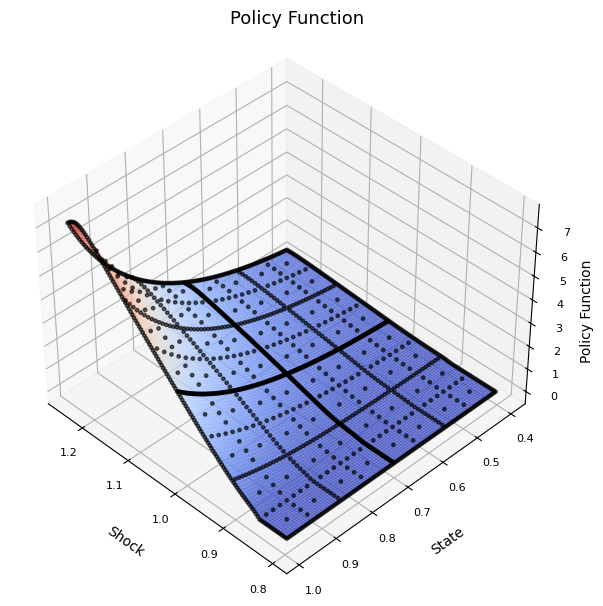

In [15]:
tool_box.plot_policy_3d(θ_end)

### Euler residuals

Despite the strong nonlinearity, the global projection produces Euler
residuals at the $10^{-5}$ median level — easily small enough for moment-
based estimation. The maximum residual is large but concentrates at the
boundary of the binding region where the implied policy is essentially
zero, making relative errors numerically ill-conditioned (the same
artefact appears in the standard DMP diagnostics above).

median residual: nan


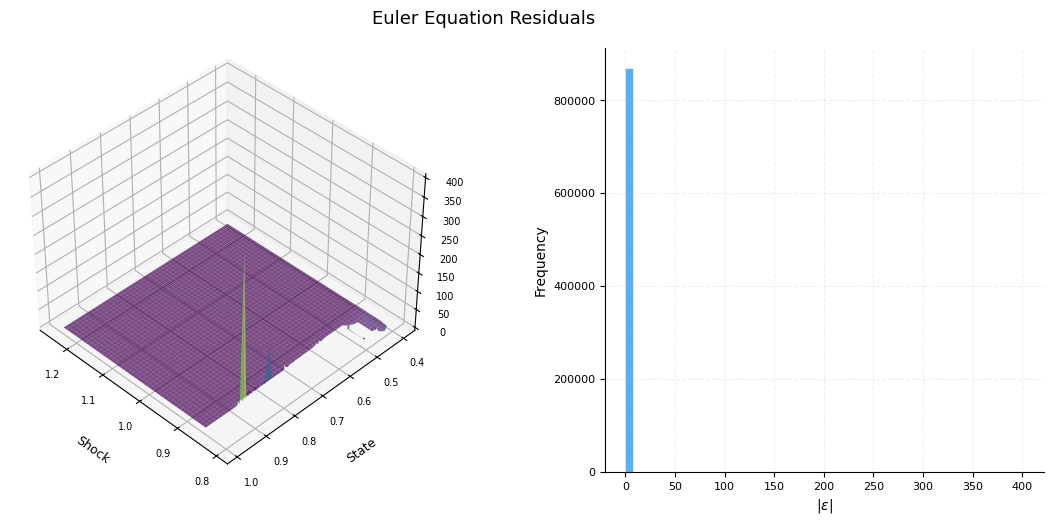

In [16]:
err_end_dmp = tool_box.compute_residuals(e_end_dmp)
print(f'median residual: {np.median(err_end_dmp):.2e}')
tool_box.plot_errors_3d()

## Summary

This notebook demonstrated the core workflow of the `sparsepea` package
across three models of increasing numerical difficulty:

1. **Specify the model** by instantiating a JIT-compiled class
   (`rbc_jit`, `dmp_jit`, `end_dmp_jit`).
2. **Build the sparse grid** — `make_states_grid()` returns the Tasmanian
   grid and its node coordinates.
3. **Solve** via damped PEA fixed-point iteration; `compute_solution`
   returns $(\psi, \text{policy}, \mu, \text{status})$. The `damping`
   parameter defaults to $1.0$; lower it (e.g. $0.1$) when the model
   has strong amplification mechanisms such as a consumption-based SDF.
4. **Diagnose** solution quality via `compute_residuals` and the
   `plot_errors_3d` visualisation.

The same interface generalises to any model that can be cast in the form
$\psi(\mathbf{s}) = \mathbb{E}[h(\mathbf{s}, \mathbf{s}')]$ with
complementarity conditions. Adding a new model amounts to writing a
`@jitclass` that implements `x_axis_grid`, `rhs_euler`, `c_implied`, and
`ar1_conditional_density` — the solver handles everything else.

For a quantitative application that compares simulated moments against
published results, see the companion notebook
`petrosky_nadeau_zhang_replication.ipynb`.